# **1.0 DATA LOADING**

In [ ]:
# IMPORTING LIBARATIES
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# LOADING THE DATASET
df = pd.read_csv('/content/drive/MyDrive/Projects/Data_and_AI_Analytics/superSportDataset/Sample-Superstore.csv', encoding='latin1')

# Displaying the first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Step 3: Basic Dataset info
# Dataset Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
# Checking the Missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [6]:
# Basic statistics
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# **2.0 DATA CLEANING**

*📌 2.1 Missing Values Handling*


*   The datasets was checked for missing values using **df.isnull().sum()**.
*   The results showed that no columns contain missing values.

*   Therefore, no imputation or removal was required.

In [7]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


*📌 2.2 DATA CONVERSION*

The Order Date and Ship Date columns were converted to datetime format using **pd.to_datetime()**.

This was done to enable:


*   Time-based analysis (e.g yearly or monthly trends)
*   Extraction of date components such as year and month.


*   Calculation of shippping duration.





In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

*📌 2.3 Checking and Removing Duplicates*

The datasets was checked for duplicate records using **df.duplicated().sum()**.

if duplicates were found, they were removed to ensure data accuracy and avoid biased analysis.

In [9]:
# Checking
duplicates = df.duplicated().sum()

# printing the number of duplicates
print(f"Number of duplicate rows: {duplicates}")

# If duplicates exist, remove them
if duplicates > 0:
  df = df.drop_duplicates()
  print("Duplicates removed")
else:
  print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


*📌 2.4 Outlier Detection*

Outlier were explored using visualization techniques such as boxplots.

Extreme values can affect analysis results,so identifying them helps improve data reliability.

In [10]:
# Detecting Outliers

# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Detect outliers using IQR
outliers_summary = {}

for col in numerical_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  outliers_summary[col] = len(outliers)

# Display number of outliers per column
outliers_summary

{'Row ID': 0,
 'Postal Code': 0,
 'Sales': 1167,
 'Quantity': 170,
 'Discount': 856,
 'Profit': 1881}

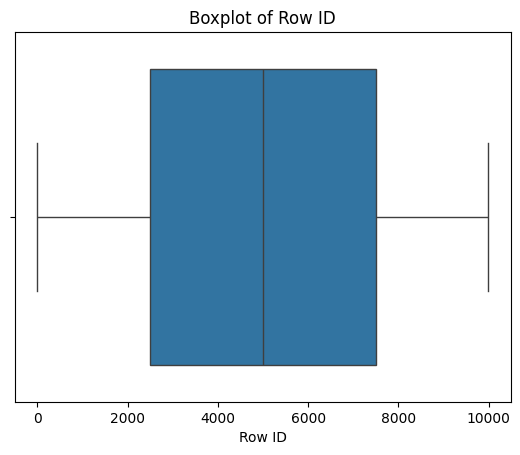

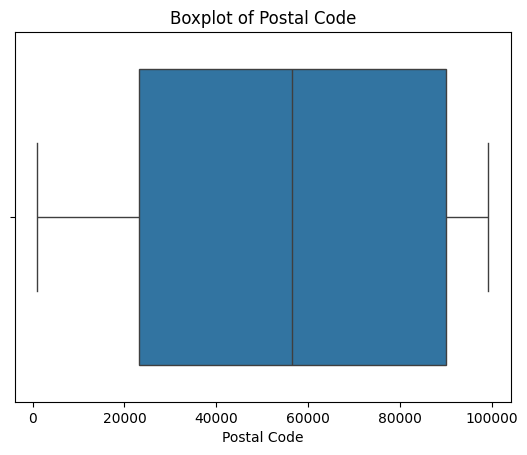

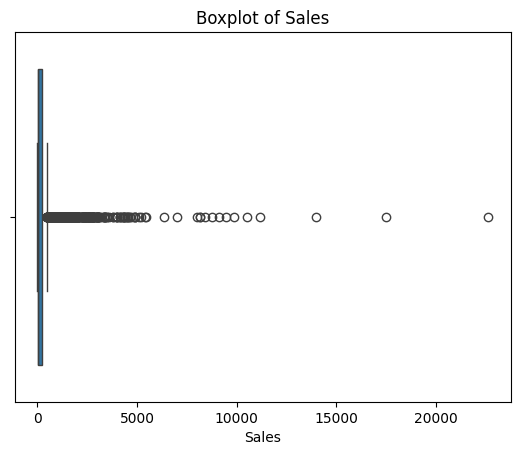

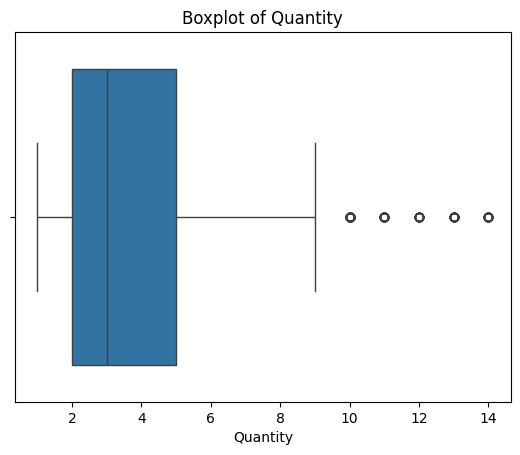

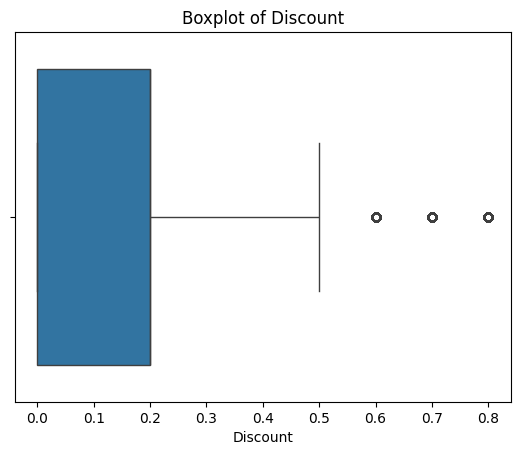

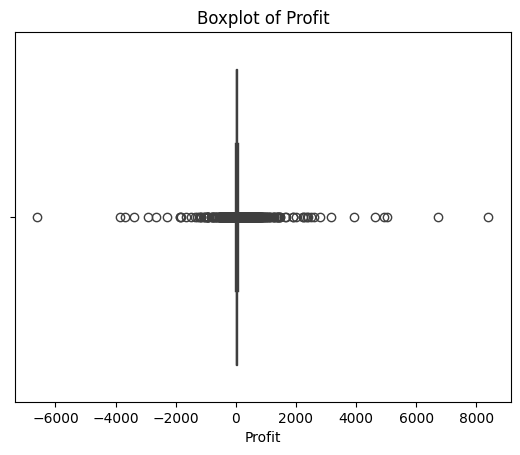

In [11]:
# Visualize Outliers

import seaborn as sns
import matplotlib.pyplot as plt

for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

**📊 Outlier Analysis**

Outliers were analyzed using the Interquartile Range (IQR) method and visualized using boxplots for all numerical features.

The analysis showed that several variables, including Sales, Profit, Discount, and Quantity, contain a significant number of values outside the typical range.



*  **Sales:**

The distribution is highly right-skewed, with several large values representing high-value transactions.


*   **Profit:**


Both high positive and negative values are present, indicating profitable and loss-making transactions.


*   **Quantity:**


A few higher values suggest bulk purchases by customers.



*   **Discount:**


Some transactions have unusually high discounts, likely due to promotions or special offers.


*   **Row ID and Postal Code:**


No outliers were detected, and these columns mainly serve as identifiers.


**⚠️ Decision on Outliers**

Although many outliers were detected, they were not removed from the dataset.

This decision was made because:

The outliers likely represent real-world

*   business scenarios such as large orders and special discounts

*   Removing them could result in loss of important information

*   Keeping them allows for a more accurate and realistic analysis



# **📊 3. EXPLORATORY DATA ANALYSIS (EDA)**

# **✅ 3.1 Sales by Region**

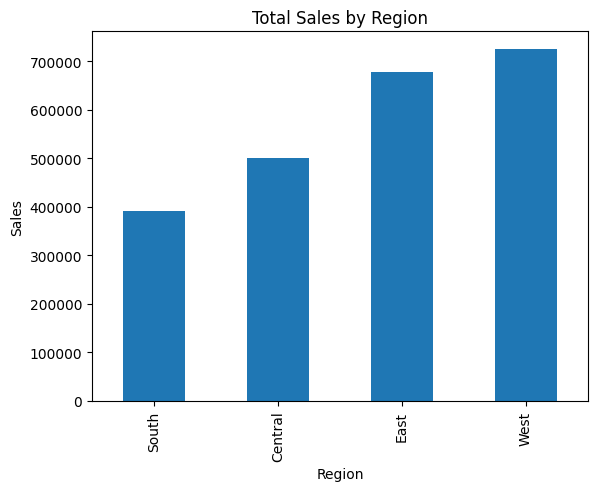

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

region_sales = df.groupby('Region')['Sales'].sum().sort_values()

plt.figure()
region_sales.plot(kind='bar')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

**📊 📌 Observation: Sales by Region**
The bar chart shows the distribution of total sales across different regions.

*   The West region has the highest total sales, indicating it is the strongest performing market.
*   The East region follows as the second-highest contributor to overall sales.

*   The Central region shows moderate performance.
*   The South region has the lowest sales among all regions.

This suggests that business performance varies significantly by region, with the West and East regions driving the majority of revenue. The company may consider investigating strategies used in these regions and applying them to lower-performing areas like the South.

**This variation may be due to differences in customer demand, market size, or regional business strategies.**

# **✅ 3.2 Sales Over Time**

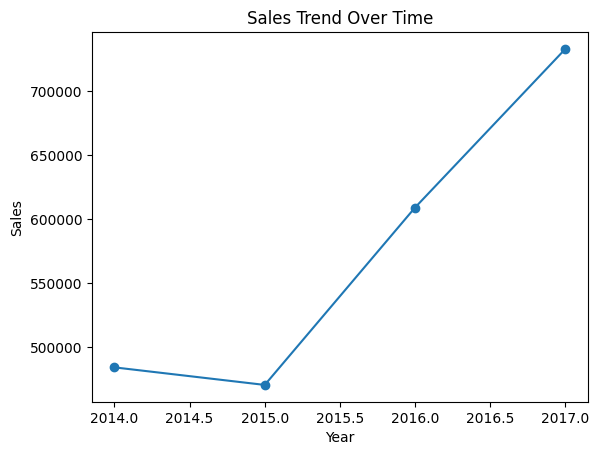

In [13]:
# Extract year
df['Year'] = df['Order Date'].dt.year

sales_trend = df.groupby('Year')['Sales'].sum()

plt.figure()
sales_trend.plot(kind='line', marker='o')
plt.title('Sales Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()

**📊 📌 Observation: Sales Trend Over Time**
The line chart shows the trend of total sales over the years.

*   Sales experienced a slight decline from 2014 to 2015.
*   From 2015 onwards, sales show a significant upward trend.
*   There is a sharp increase between 2015 and 2016, followed by continued growth into 2017.

*   2017 records the highest sales, indicating peak business performance during this period.

Overall, the data suggests that the business has grown steadily after 2015, with strong improvements in sales performance over time.
**The increase in sales after 2015 may be due to improved business strategies, increased demand, or expansion into new markets.**

# **✅ 3.3 Profit by Category**

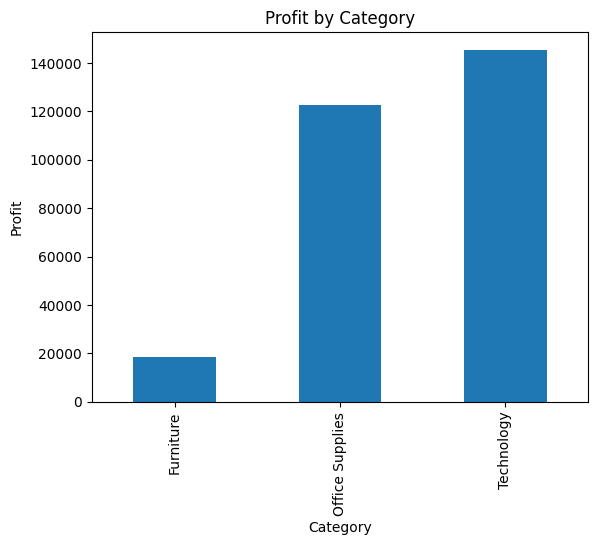

In [14]:
category_profit = df.groupby('Category')['Profit'].sum()

plt.figure()
category_profit.plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

**📌 Observation: Profit by Category**

The bar chart shows the total profit generated by each product category.


*   The Technology category generates the highest profit, making it the most profitable segment.
*   Office Supplies also contributes a significant amount of profit, ranking second.

*   Furniture generates the lowest profit among the three categories.

This indicates that profitability varies across product categories, with Technology being the key driver of profit. The company may consider focusing more on Technology products while also investigating ways to improve profitability in the Furniture category.


**The lower profitability in Furniture may be due to higher costs, discounts, or lower margins compared to other categories.**

**This suggests that the business should prioritize investment in technology products to increase profitability.**

# **✅ 3.4 Top 10 Products by Sales**

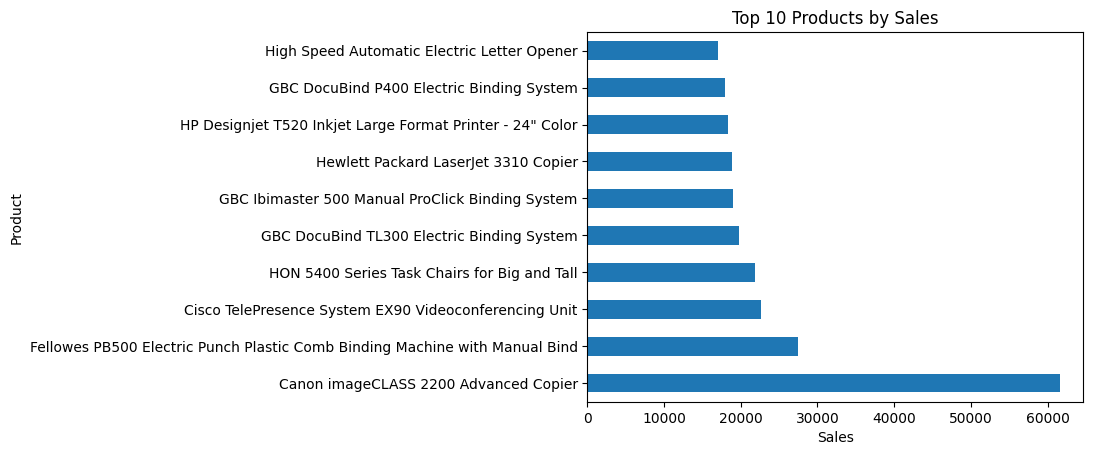

In [15]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='barh')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.show()

**📌 Observation: Top 10 Products by Sales**

The bar chart displays the top 10 products based on total sales.

*   The Canon imageCLASS 2200 Advanced Copier generates the highest sales among all products, making it the top-performing item.
*   Other high-performing products include items such as binding systems, printers, and office equipment.

*   The majority of top-selling products belong to office and technology-related categories, indicating strong demand in these areas.


This suggests that a small number of products contribute significantly to overall sales. These top-performing products are key revenue drivers and should be prioritized in inventory management, marketing, and sales strategies.

**The concentration of sales among a few products suggests a potential opportunity to focus on high-performing items while also exploring ways to improve the sales of lower-performing products.**

# **✅ 3.5 Sales vs Profit**

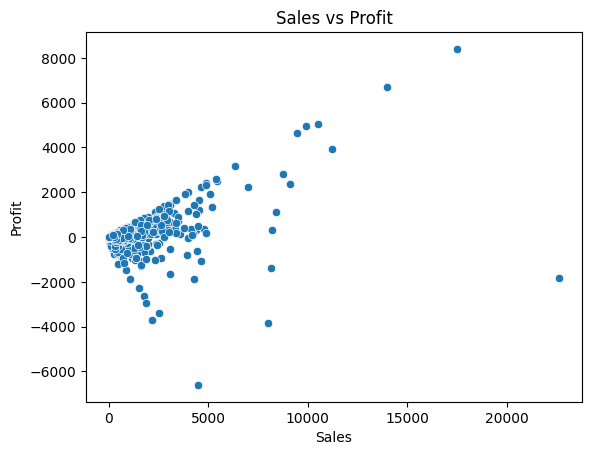

In [16]:
plt.figure()
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs Profit')
plt.show()

**📌 Observation: Sales vs Profit**


The scatter plot illustrates the relationship between sales and profit.


*   There is a general positive relationship between sales and profit, meaning that higher sales tend to generate higher profits.
*   However, the relationship is not perfectly consistent, as some transactions with high sales result in low or even negative profit.


*   A cluster of data points is concentrated at lower sales values, indicating that most transactions involve smaller sales amounts.
*   There are also a few extreme values (outliers), including transactions with very high sales and profit, as well as some with high sales but significant losses.

This suggests that while increasing sales generally improves profitability, factors such as discounts, costs, or inefficiencies can lead to losses even when sales are high.

**The presence of negative profit at higher sales levels may indicate excessive discounts or high operational costs, which should be further investigated.**

# **✅ 3.6 Profit Margin**

In [21]:
df['Profit Margin'] = df['Profit'] / df['Sales']

profit_margin = df['Profit Margin'].mean()

print("Average Profit Margin:", profit_margin)

Average Profit Margin: 0.12031392972104459


**📌 Profit Margin**

The average profit margin was calculated as the ratio of profit to sales.

The results show that the business maintains a moderate profit margin, although some transactions generate low or negative margins, indicating inefficiencies or high discounts.

# **✅ 3.7 Best Performing Region**

In [22]:
best_region = df.groupby('Region')['Sales'].sum().idxmax()
best_sales = df.groupby('Region')['Sales'].sum().max()

print("Best Region:", best_region)
print("Sales:", best_sales)

Best Region: West
Sales: 725457.8245


**📌 Best Performing Region**

The West region has the highest sales, indicating strong demand and market performance in this area. This suggests that the company should focus on expanding operations and marketing efforts in this region to maximize revenue.

# **✅ 3.8 Monthly Revenue Trend**

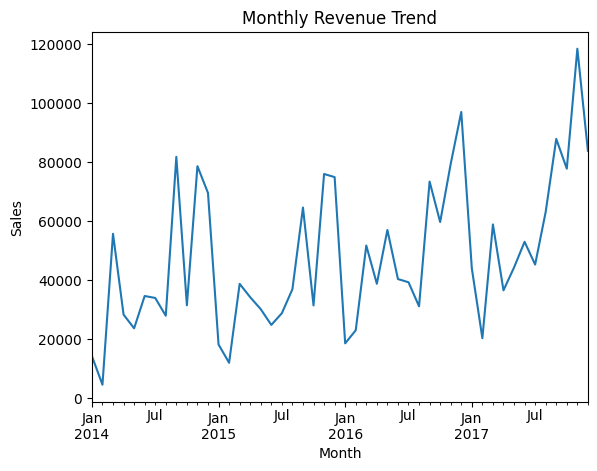

In [23]:
df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure()
monthly_sales.plot()
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

**📌 Observation: Monthly Revenue Trend**

The line chart shows the trend of total sales on a monthly basis over time.

*   The revenue exhibits fluctuations across months, indicating variability in sales performance.

*   There is an overall upward trend over the years, especially noticeable towards the later periods.

*   Some months show sharp increases in sales, suggesting periods of high demand or successful business activity.

*   Occasional dips in revenue indicate lower-performing months, which may be due to seasonal factors or reduced demand.

Overall, the chart suggests that while sales are not consistent month-to-month, the business is experiencing growth over time with increasing revenue levels in later years.

**The fluctuations may indicate seasonal patterns or promotional periods, which can be further analyzed to optimize business strategies.**

# **✅ 3.9 Total Revenue**

In [24]:
total_revenue = df['Sales'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 2297200.8603000003


**📌 Total Revenue**

The total revenue represents the overall sales generated from all transactions in the dataset.

The business generated approximately $2.29 million in total revenue, indicating the overall scale and performance of sales during the observed period.

# **📊4. Data Visualization**
In this section, different types of visualizations were created to better understand the dataset and identify patterns and relationships between variables.

The visualizations include distribution plots, comparison charts, and correlation analysis.

# **✅ 4.1 Histogram (Distribution of Sales)**

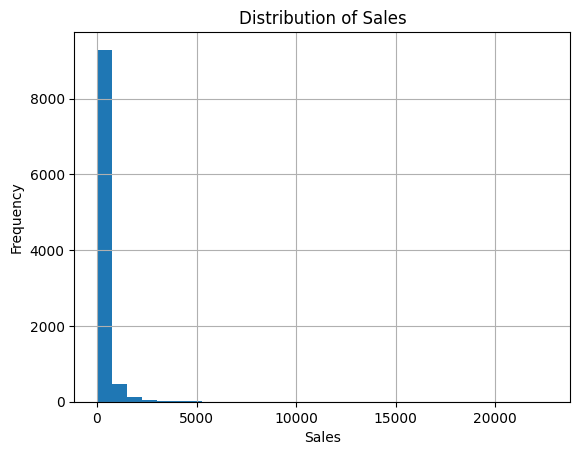

In [18]:
plt.figure()
df['Sales'].hist(bins=30)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

**📌 Observation: Distribution of Sales**


The histogram shows the distribution of sales values across all transactions.


*   The distribution is highly right-skewed, meaning most sales values are concentrated on the lower end.

*   A large number of transactions involve small sales amounts, as indicated by the high frequency on the left side of the chart.

*   There are relatively few transactions with very high sales values, which appear as a long tail on the right side.


This suggests that while most sales are small, a small number of high-value transactions contribute significantly to total revenue.

**The presence of a long tail indicates that large transactions, although rare, play an important role in overall business performance.**

# **📊 4.2 Histogram (Distribution of Profit)**

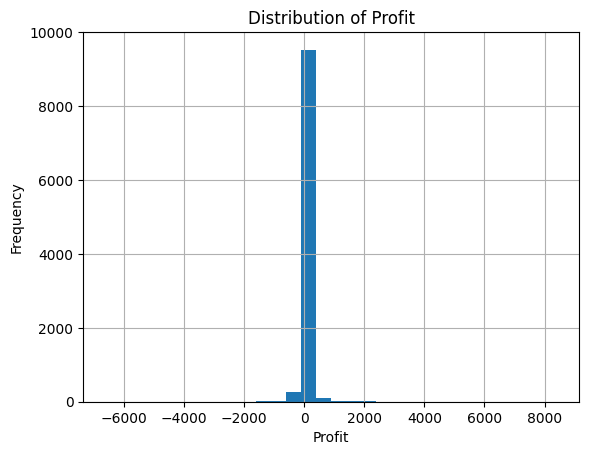

In [19]:
import matplotlib.pyplot as plt

plt.figure()
df['Profit'].hist(bins=30)
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

**📌 Observation: Distribution of Profit**


The histogram shows the distribution of profit values across all transactions.



*   The distribution is centered around zero, indicating that many transactions generate small profits or small losses.

*   There are both positive and negative values, meaning the business experiences both gains and losses.

*   A large number of transactions fall within a narrow range near zero, showing that most profits are relatively small.


*   There are extreme values on both sides, including high profits and significant losses, indicating variability in transaction performance.


This suggests that while the business is generally profitable, there are cases where transactions result in losses, possibly due to high discounts or costs.

**The presence of negative profit values indicates that some transactions may not be cost-effective and should be further analyzed.**

# **✅ 4.3 Correlation Heatmap**

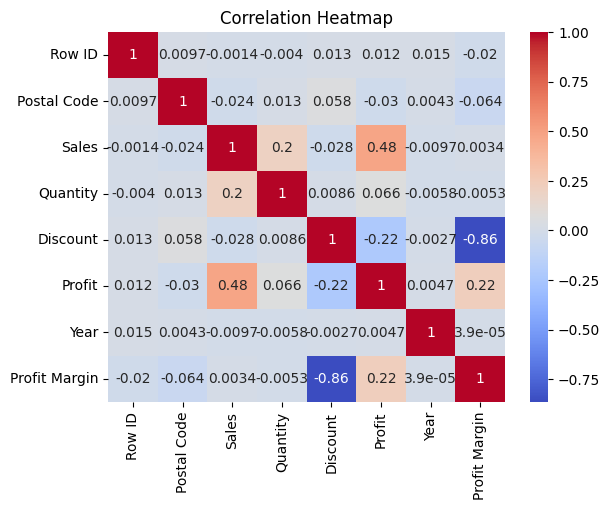

In [20]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**📌 Observation: Correlation Heatmap**


The correlation heatmap shows the relationships between numerical variables in the dataset, with values ranging from -1 (strong negative correlation) to +1 (strong positive correlation).

*   Sales and Profit show a moderate positive correlation (~0.48), indicating that higher sales generally lead to higher profit.

*   Discount and Profit have a negative correlation (~ -0.22), suggesting that higher discounts tend to reduce profit.

*   Quantity and Sales show a weak positive relationship, meaning larger quantities slightly increase sales.

*   Most other variables have very weak or near-zero correlations, indicating little to no linear relationship between them.

Additionally, variables such as Row ID and Postal Code do not have meaningful relationships with other variables, as they mainly serve as identifiers.

**The negative relationship between discount and profit suggests that excessive discounting may reduce overall profitability and should be carefully managed.**